# Individual Anomaly Detection Models for Each Dataset
This notebook demonstrates how to train an individual anomaly detection model for each dataset and visualize the differences.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import glob
import os

## Load All Datasets
We will load all CSV files from the 'FEB 2025 Prototype data' directory.

In [ ]:
# Load all datasets
data_dir = '/home/understressengineer/programming/SRM_PS1/FEB 2025 Prototype data'
csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
datasets = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f) for f in csv_files}
print('Loaded datasets:', list(datasets.keys()))

/tmp/ipykernel_48062/787206042.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  datasets = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f) for f in csv_files}


Loaded datasets: ['WR', 'NR', 'NCR', 'CR', 'SCR', 'NFR', 'ECOR', 'ECR', 'WCR', 'SR', 'NER', 'SECR']


: 

## Train Isolation Forest for Each Dataset and Plot Differences


Processing WR...


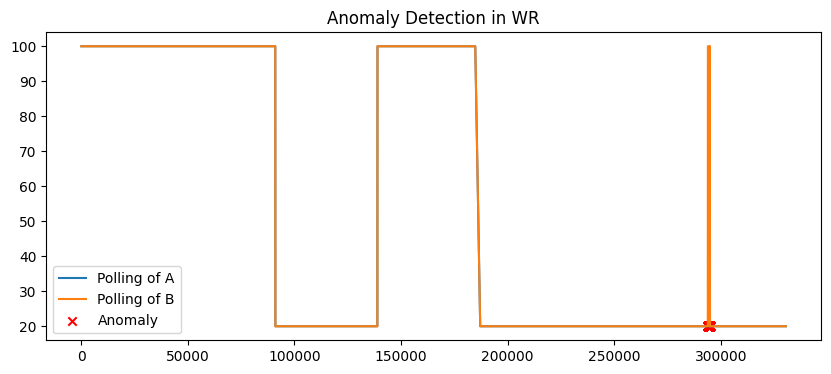

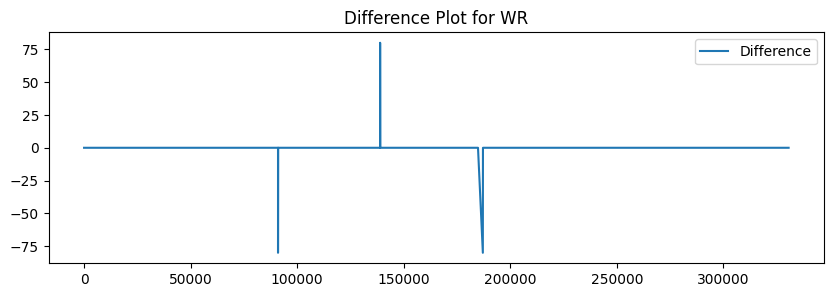


Processing NR...


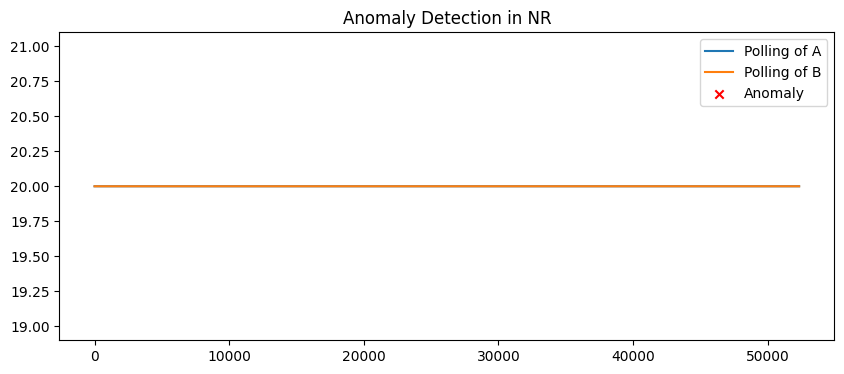

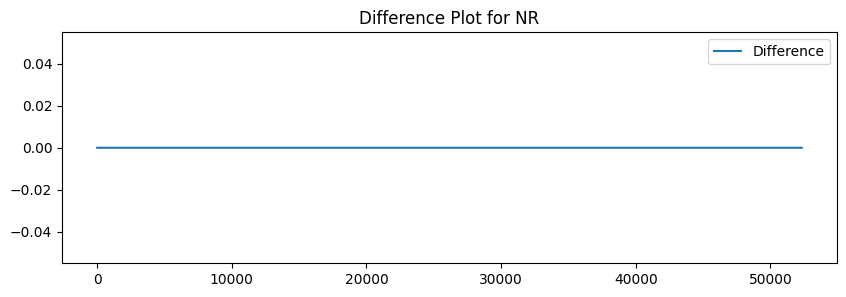


Processing NCR...


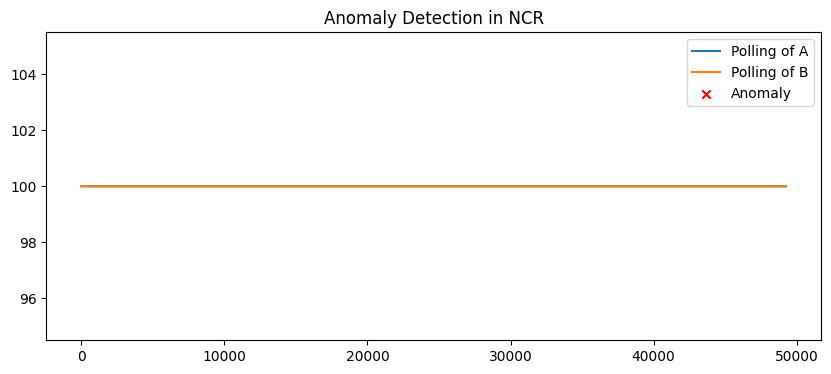

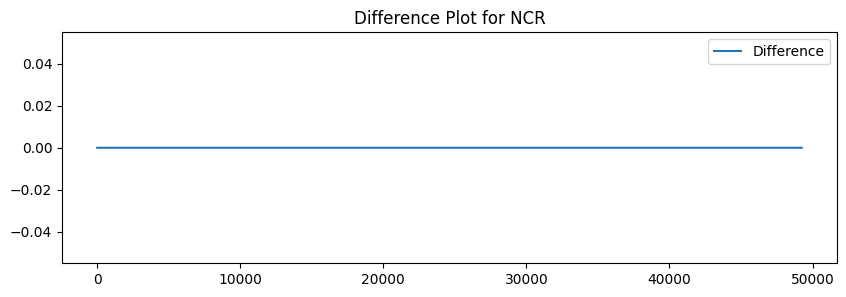


Processing CR...


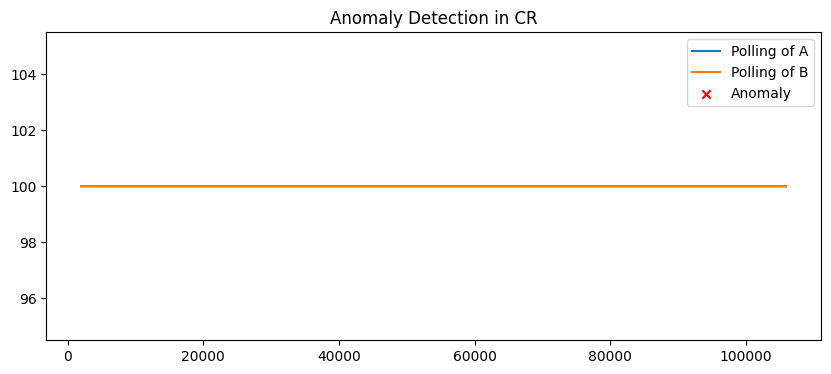

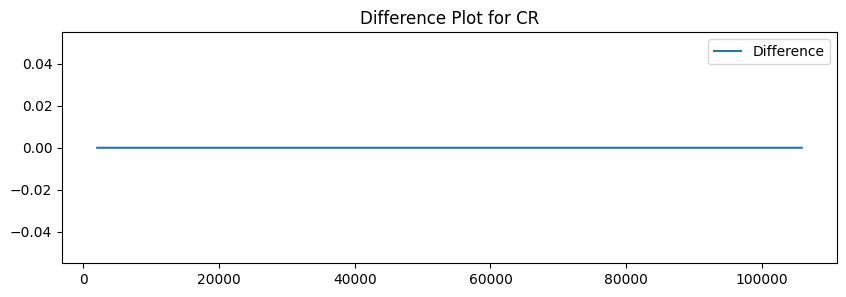


Processing SCR...


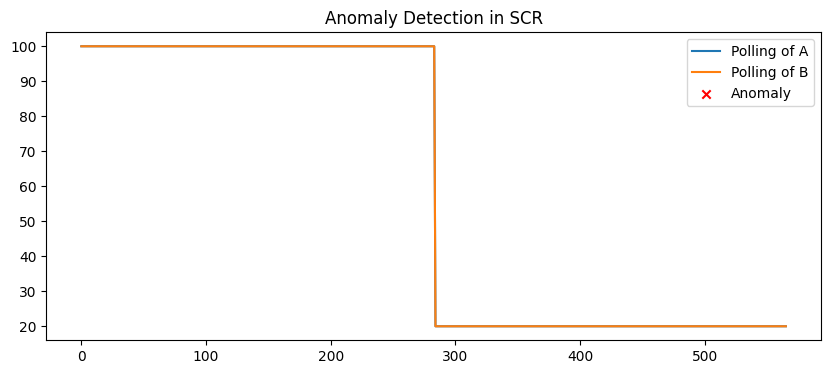

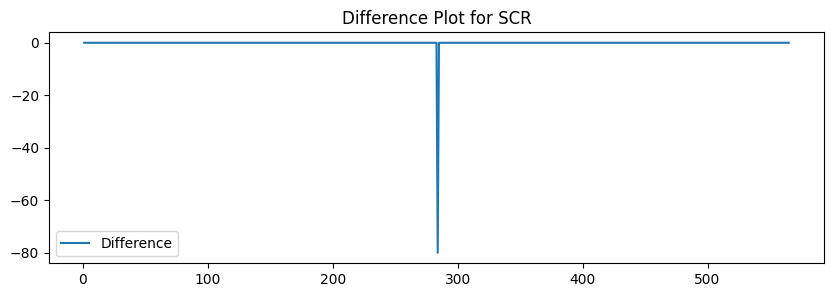


Processing NFR...


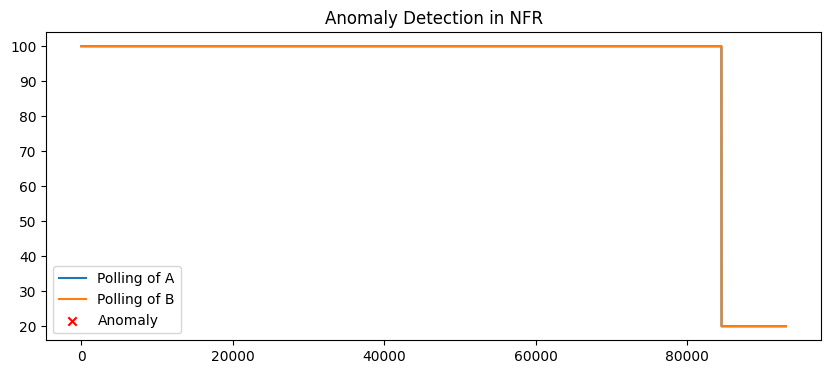

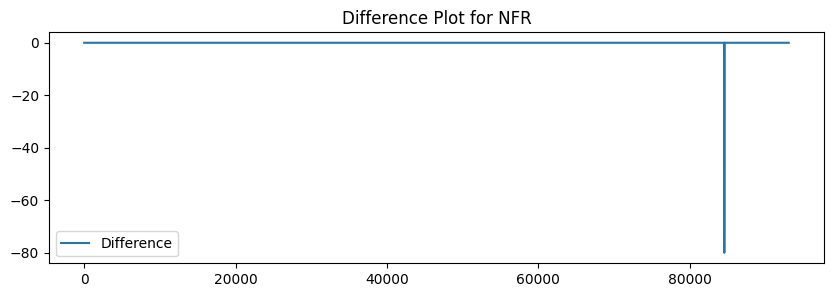


Processing ECOR...


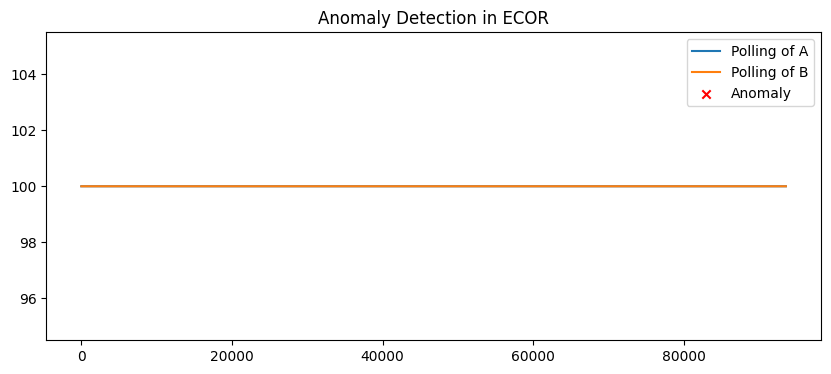

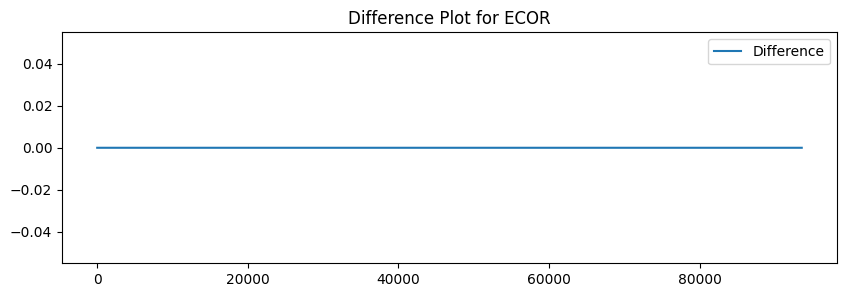


Processing ECR...


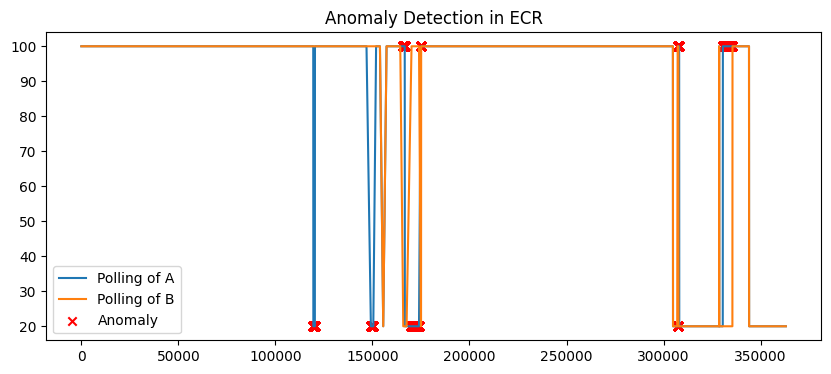

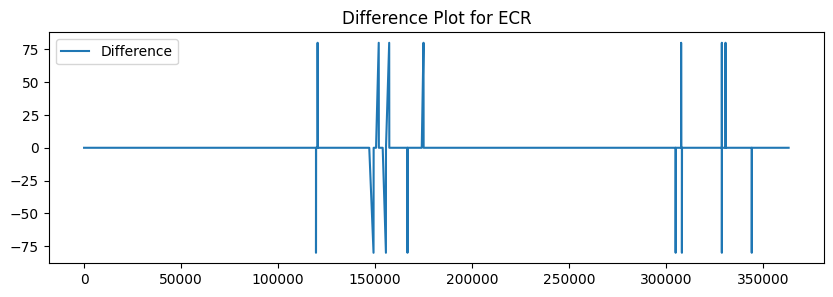


Processing WCR...


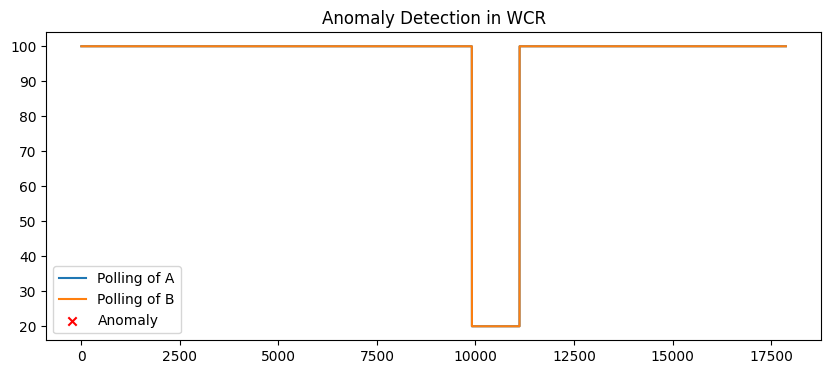

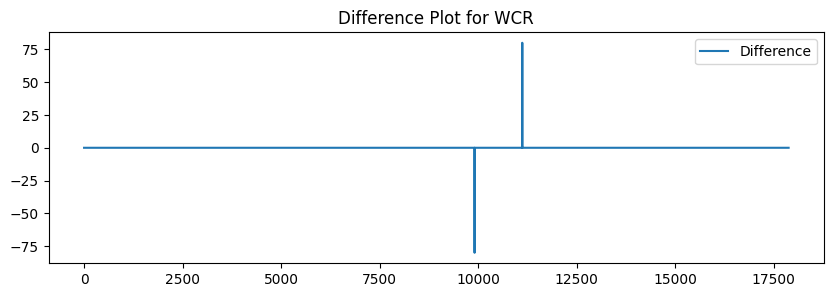


Processing SR...


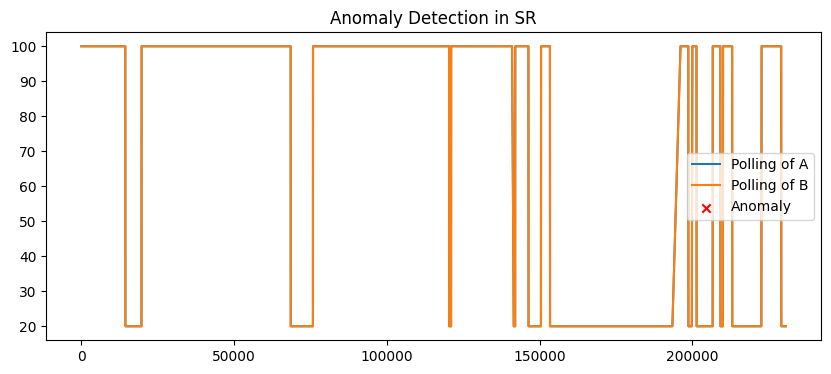

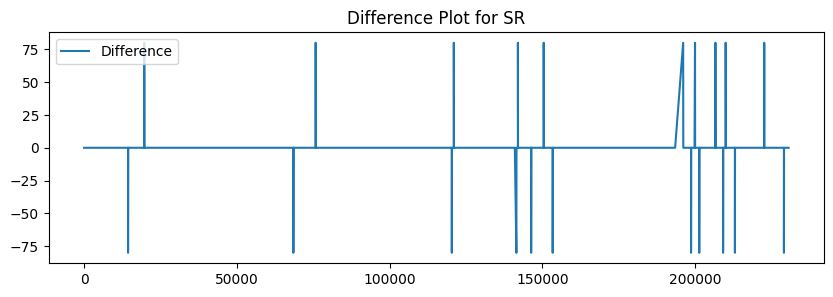


Processing NER...


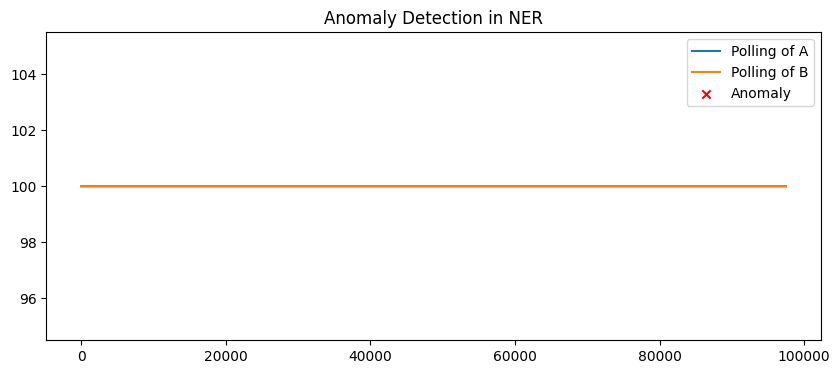

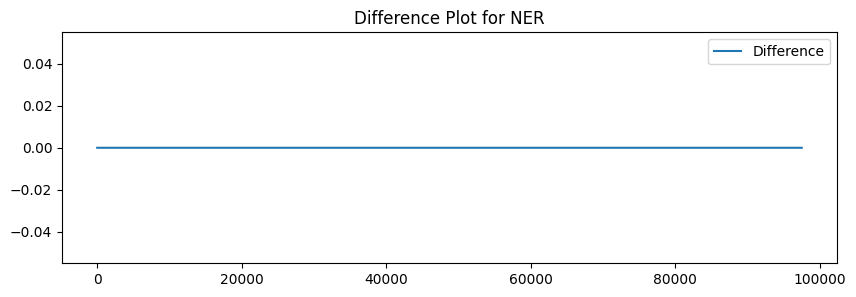


Processing SECR...


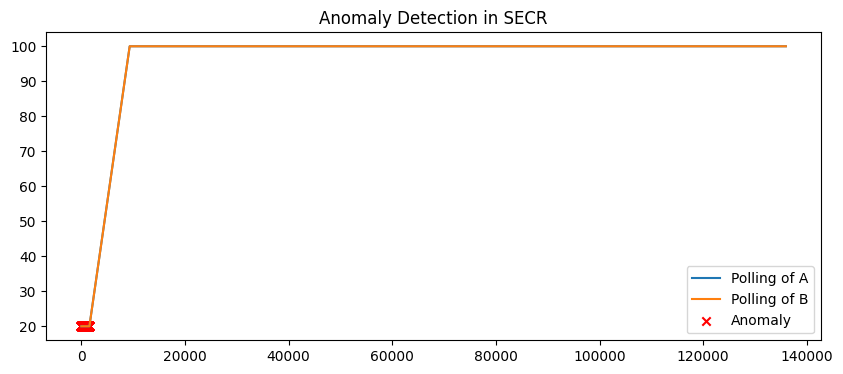

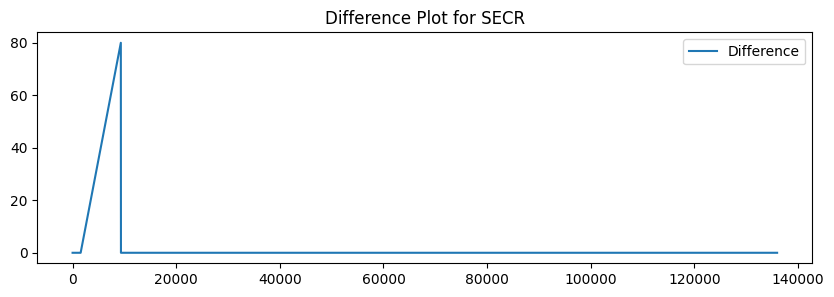

In [6]:
# For each dataset, train an Isolation Forest and plot anomalies
for name, df in datasets.items():
    print(f'\nProcessing {name}...')
    # Simple preprocessing: drop non-numeric columns
    df_num = df.select_dtypes(include=[np.number]).dropna()
    if df_num.shape[1] == 0:
        print(f'No numeric columns in {name}, skipping.')
        continue
    # Train Isolation Forest
    model = IsolationForest(contamination=0.05, random_state=42)
    preds = model.fit_predict(df_num)
    df_num['anomaly'] = preds
    # Plot
    plt.figure(figsize=(10, 4))
    for col in df_num.columns[:-1]:
        plt.plot(df_num.index, df_num[col], label=col)
    plt.scatter(df_num.index[df_num['anomaly'] == -1], df_num[df_num['anomaly'] == -1][df_num.columns[0]], color='red', label='Anomaly', marker='x')
    plt.title(f'Anomaly Detection in {name}')
    plt.legend()
    plt.show()
    # Plot difference (if time series)
    if df_num.shape[1] > 2:
        diff = df_num.iloc[:, 0].diff()
        plt.figure(figsize=(10, 3))
        plt.plot(df_num.index, diff, label='Difference')
        plt.title(f'Difference Plot for {name}')
        plt.legend()
        plt.show()


Plotting columns for WR...


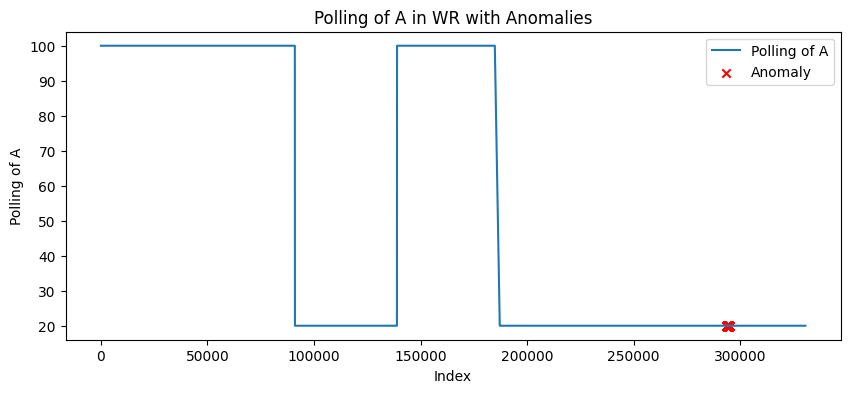

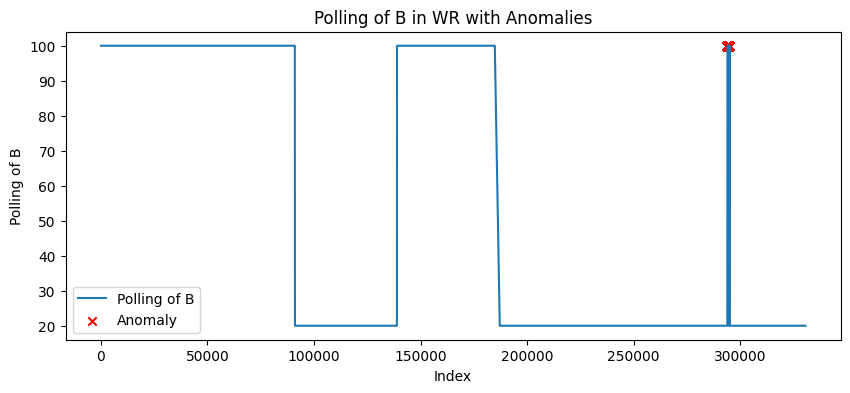


Plotting columns for NR...


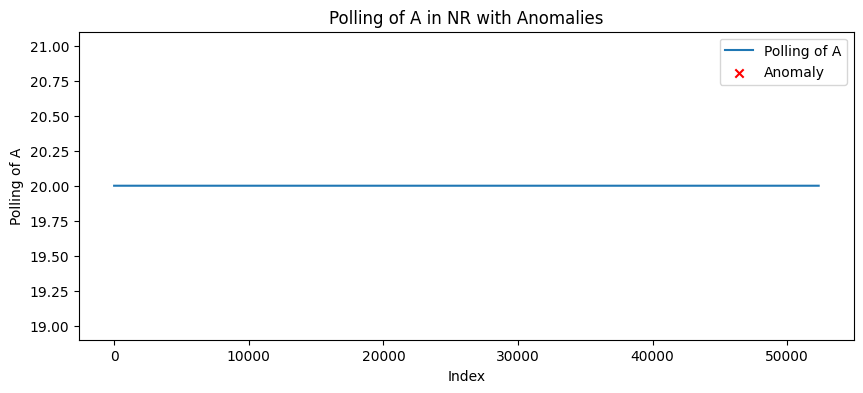

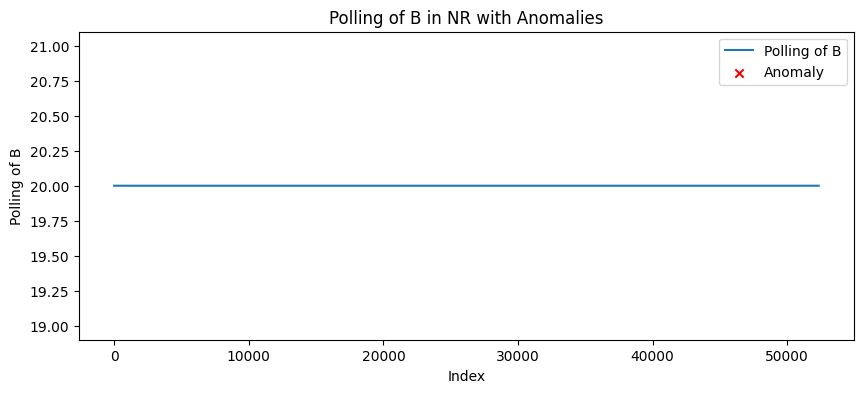


Plotting columns for NCR...


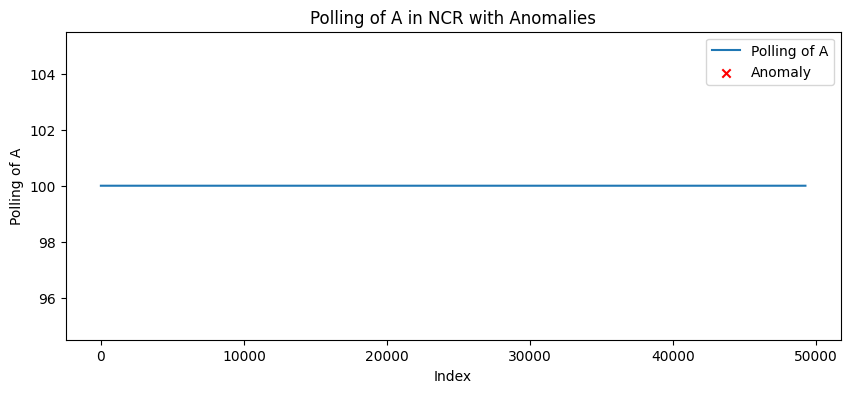

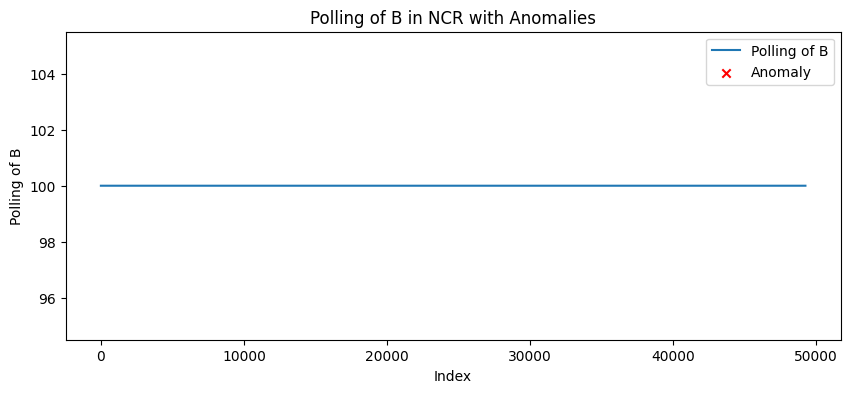


Plotting columns for CR...


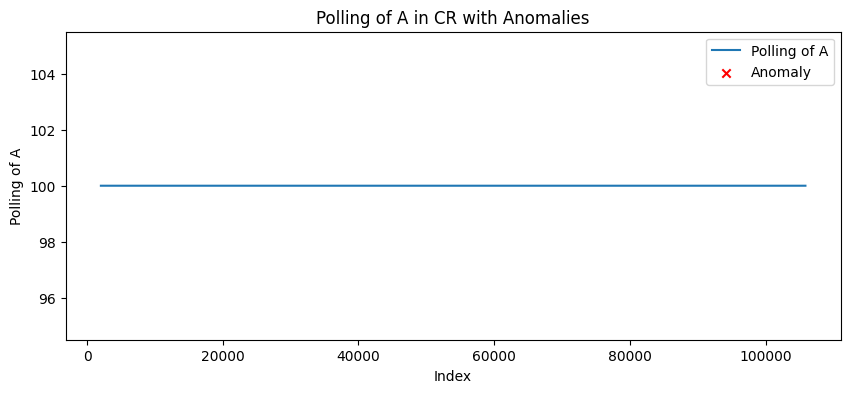

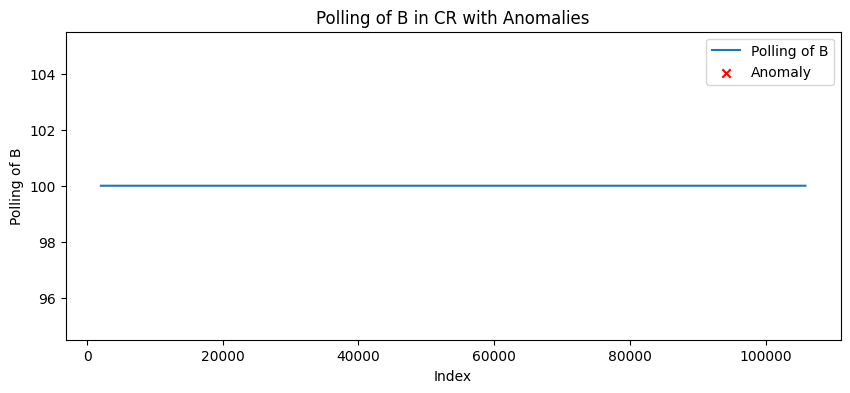


Plotting columns for SCR...


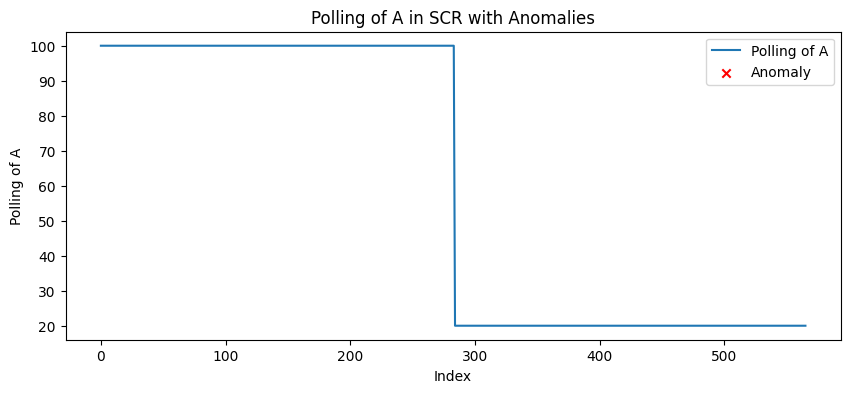

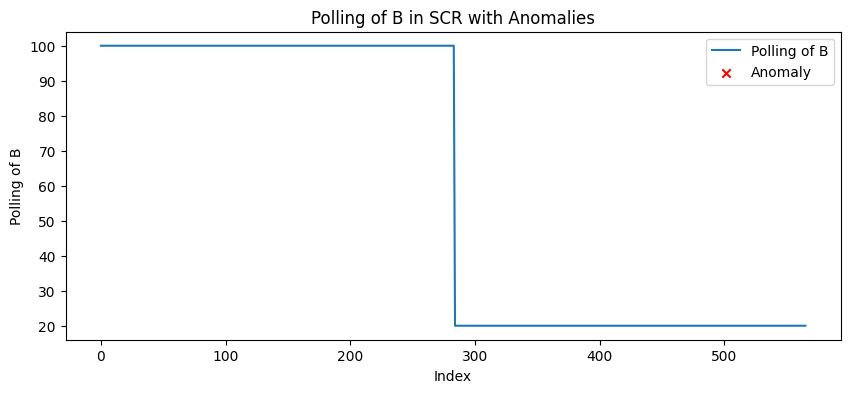


Plotting columns for NFR...


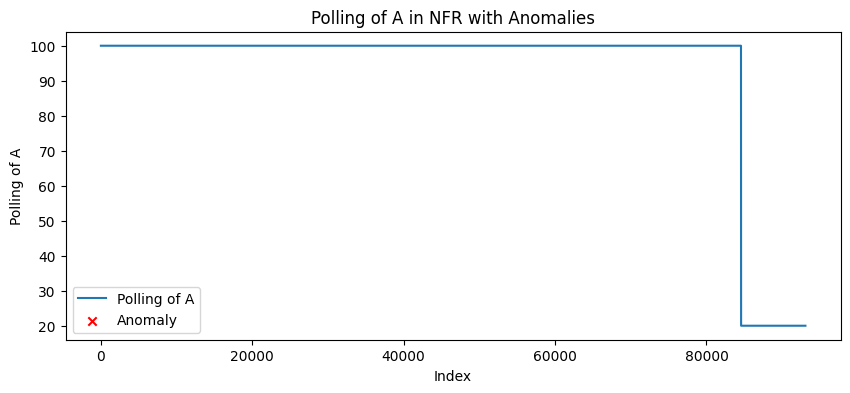

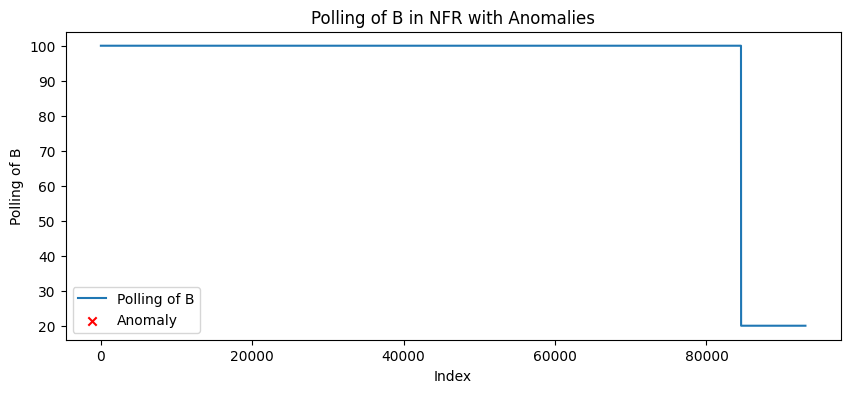


Plotting columns for ECOR...


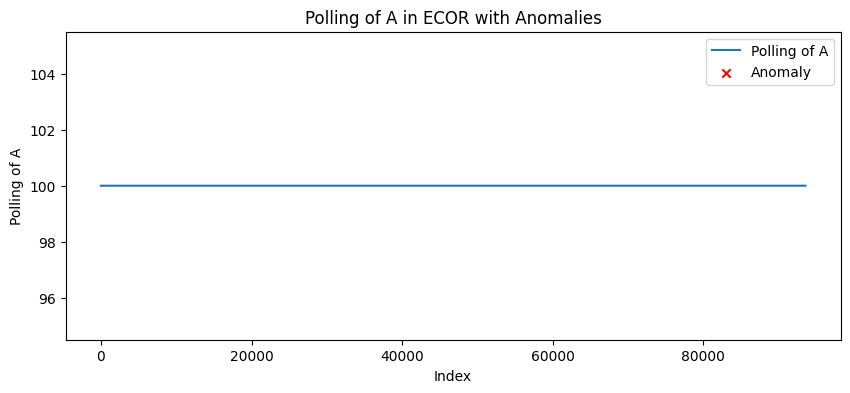

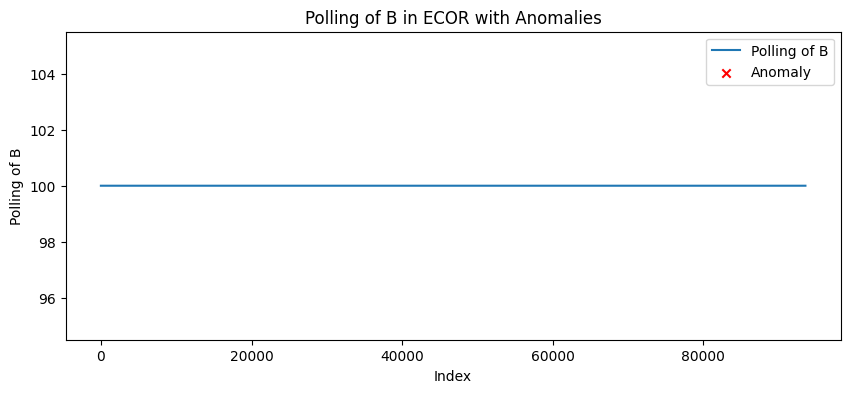


Plotting columns for ECR...


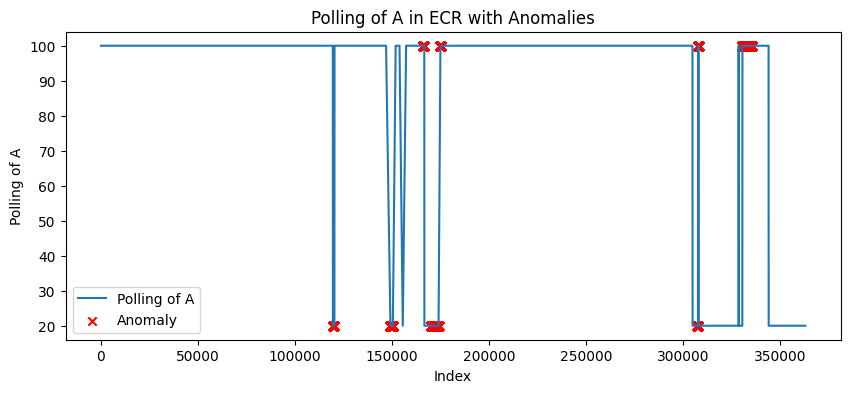

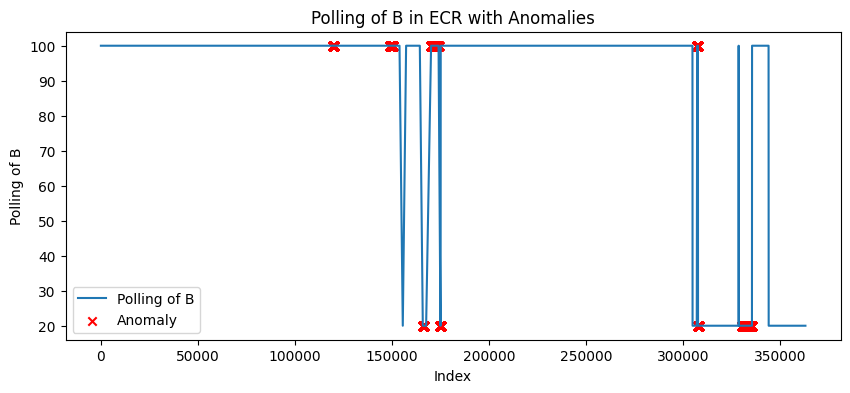


Plotting columns for WCR...


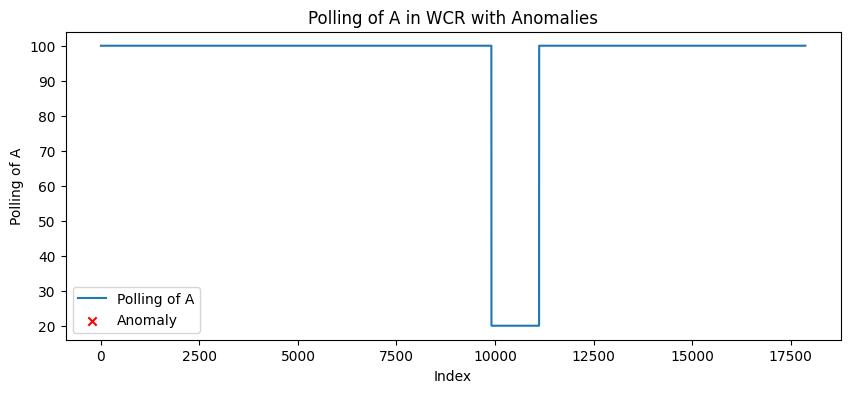

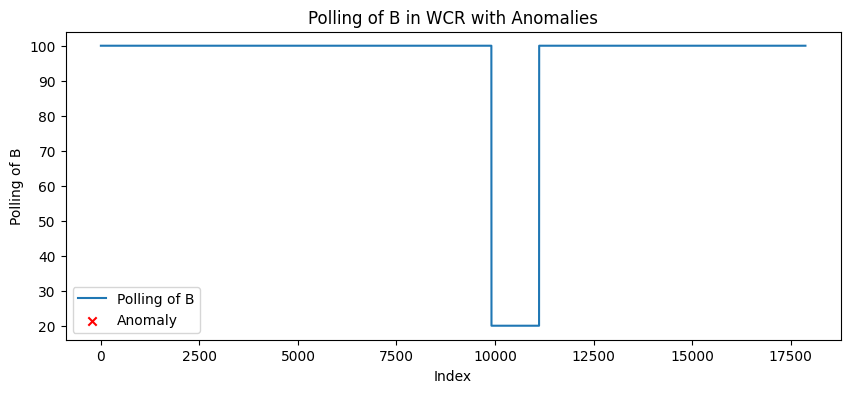


Plotting columns for SR...


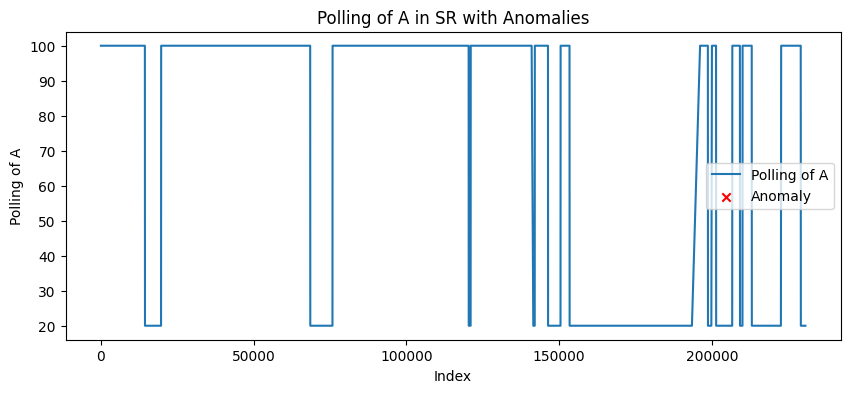

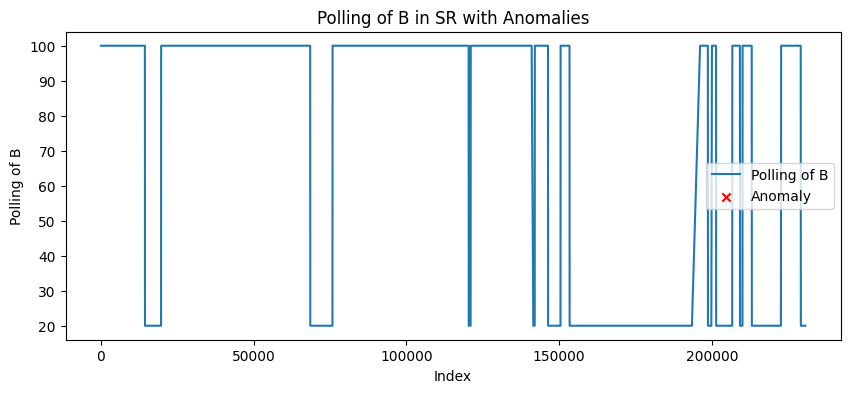


Plotting columns for NER...


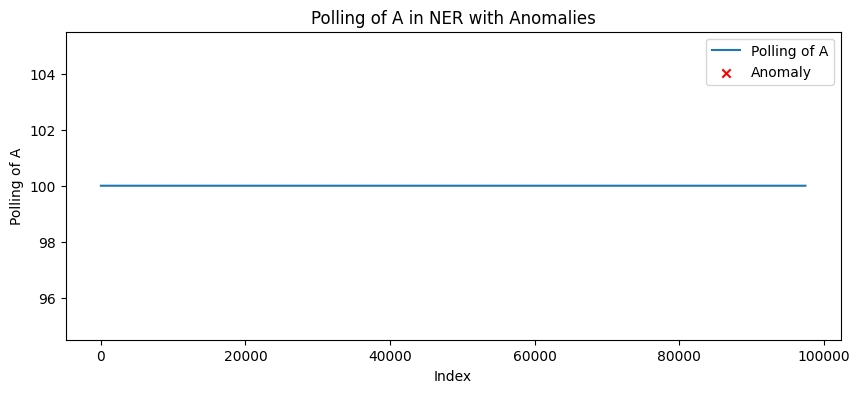

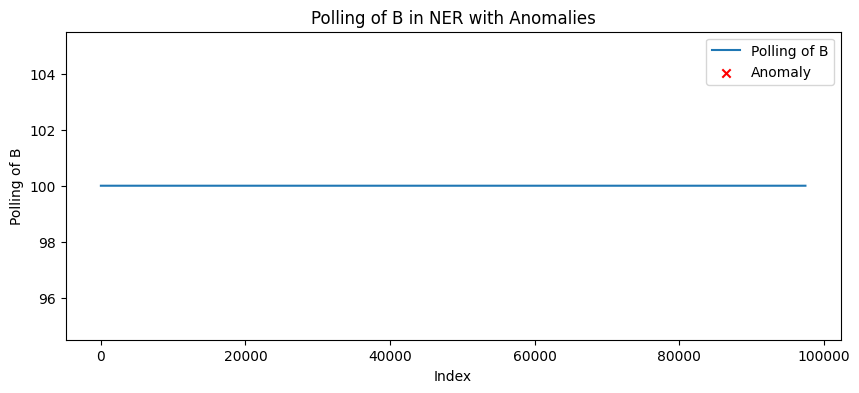


Plotting columns for SECR...


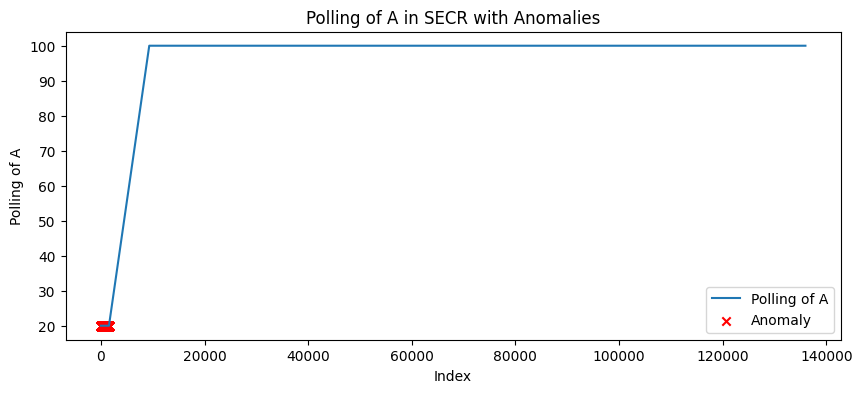

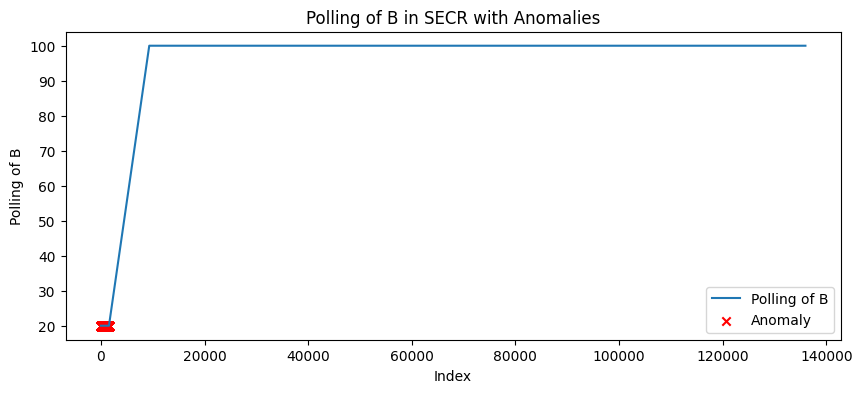

In [7]:
# Plot each numeric column individually for all datasets, highlighting anomalies
for name, df in datasets.items():
    print(f"\nPlotting columns for {name}...")
    df_num = df.select_dtypes(include=[np.number]).dropna()
    if df_num.shape[1] == 0:
        print(f"No numeric columns in {name}, skipping.")
        continue
    # Train Isolation Forest
    model = IsolationForest(contamination=0.05, random_state=42)
    preds = model.fit_predict(df_num)
    df_num['anomaly'] = preds
    for col in df_num.columns[:-1]:  # Exclude 'anomaly' column
        plt.figure(figsize=(10, 4))
        plt.plot(df_num.index, df_num[col], label=col)
        plt.scatter(df_num.index[df_num['anomaly'] == -1], df_num.loc[df_num['anomaly'] == -1, col], color='red', label='Anomaly', marker='x')
        plt.title(f'{col} in {name} with Anomalies')
        plt.xlabel('Index')
        plt.ylabel(col)
        plt.legend()
        plt.show()

# Overlayed Signal Comparison for All Datasets
This section overlays A Current, A Voltage, B Current, B Voltage, Polling of A, and Polling of B for each dataset in the 'FEB 2025 Prototype data' folder. Use these plots to visually compare spikes across all signals for each dataset.

In [9]:
# Overlay plots for each dataset: A Current, A Voltage, B Current, B Voltage, Polling of A, Polling of B

def pad_array(arr, target_len):
    if len(arr) < target_len:
        return np.pad(arr, (0, target_len - len(arr)), mode='constant', constant_values=np.nan)
    return arr

def parse_signal_column(col):
    if pd.isnull(col):
        return np.array([])
    if isinstance(col, str):
        return np.array([float(x) for x in col.split(',') if x.strip() != ''])
    return np.array(col)

for name, df in datasets.items():
    print(f'\nPlotting overlay for {name}...')
    signals = {}
    for col in ['A Current', 'A Voltage', 'B Current', 'B Voltage']:
        if col in df.columns:
            signals[col] = df[col].apply(parse_signal_column)
        else:
            signals[col] = pd.Series([np.array([])] * len(df))
    # Find the max length of any signal in this dataset (for x-axis)
    max_len = 1
    for sig in signals.values():
        max_len = max(max_len, max((len(arr) for arr in sig if len(arr) > 0), default=1))
    plt.figure(figsize=(14, 6))
    for col, color in zip(['A Current', 'A Voltage', 'B Current', 'B Voltage'], ['b', 'g', 'r', 'm']):
        for arr in signals[col]:
            if len(arr) > 0:
                arr_padded = pad_array(arr, max_len)
                plt.plot(np.arange(max_len), arr_padded, color=color, alpha=0.05)
        # Stack padded arrays for mean
        arrs_to_stack = [pad_array(arr, max_len) for arr in signals[col] if len(arr) > 0]
        if arrs_to_stack:
            stacked = np.stack(arrs_to_stack)
            mean_signal = np.nanmean(stacked, axis=0)
        else:
            mean_signal = np.zeros(max_len)
        plt.plot(np.arange(max_len), mean_signal, color=color, label=col, linewidth=2)
    if 'Polling of A' in df.columns:
        plt.scatter([0]*len(df), df['Polling of A'], color='c', label='Polling of A', marker='o', alpha=0.5)
    if 'Polling of B' in df.columns:
        plt.scatter([max_len-1]*len(df), df['Polling of B'], color='y', label='Polling of B', marker='x', alpha=0.5)
    plt.title(f'Overlayed Signals for {name}')
    plt.xlabel('Sample Index (within event)')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.tight_layout()
    plt.show()


Plotting overlay for WR...


: 

: 

: 


Plotting overlay for WR...


: 

: 

: 

In [4]:
# Overlay all signals for each dataset on a single plot (one plot per dataset)

def parse_signal_column(col):
    if pd.isnull(col):
        return np.array([])
    if isinstance(col, str):
        return np.array([float(x) for x in col.split(',') if x.strip() != ''])
    return np.array(col)

for name, df in datasets.items():
    print(f"\nPlotting all signals for {name}...")
    plt.figure(figsize=(14, 6))
    colors = {
        'A Current': 'b',
        'A Voltage': 'g',
        'B Current': 'r',
        'B Voltage': 'm',
        'Polling of A': 'c',
        'Polling of B': 'y'
    }
    # Plot each signal as a faded line for each row, then overlay mean
    for col in ['A Current', 'A Voltage', 'B Current', 'B Voltage']:
        if col in df.columns:
            signals = df[col].apply(parse_signal_column)
            max_len = max((len(arr) for arr in signals if len(arr) > 0), default=0)
            # Plot all events
            for arr in signals:
                if len(arr) > 0:
                    plt.plot(np.arange(len(arr)), arr, color=colors[col], alpha=0.05)
            # Plot mean
            arrs_to_stack = [np.pad(arr, (0, max_len - len(arr)), constant_values=np.nan) for arr in signals if len(arr) > 0]
            if arrs_to_stack:
                mean_signal = np.nanmean(np.stack(arrs_to_stack), axis=0)
                plt.plot(np.arange(max_len), mean_signal, color=colors[col], label=col, linewidth=2)
    # Plot polling values as scatter
    if 'Polling of A' in df.columns:
        plt.scatter([0]*len(df), df['Polling of A'], color=colors['Polling of A'], label='Polling of A', marker='o', alpha=0.5)
    if 'Polling of B' in df.columns:
        # Use max_len from above if available, else 0
        plt.scatter([max_len-1]*len(df), df['Polling of B'], color=colors['Polling of B'], label='Polling of B', marker='x', alpha=0.5)
    plt.title(f'Overlayed Signals (within {name})')
    plt.xlabel('Sample Index (within event)')
    plt.ylabel('Signal Value')
    plt.legend()
    plt.tight_layout()
    plt.show()


Plotting all signals for WR...


: 

: 